In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error
# Pengaturan visualisasi
plt.style.use('fivethirtyeight')

Langkah 1 : Persiapan Data (Tren Linear)

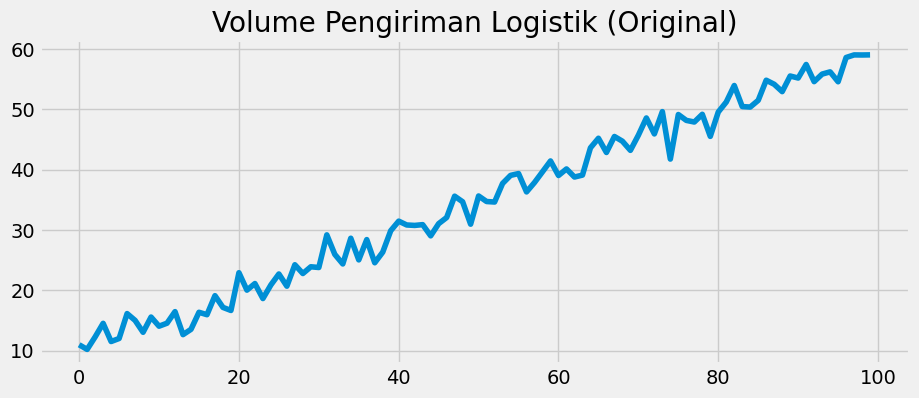

In [86]:
# Membuat data sintetis
np.random.seed(42)
t = np.arange(100)
# Data memiliki tren (0.5*t) dan variansi acak
y = 10 + 0.5 * t  + np.random.normal(0,2, 100)
df = pd.DataFrame({'Volume' : y})

# Visualisasi Data Awal
df['Volume'].plot(figsize=(10, 4), title='Volume Pengiriman Logistik (Original)')
plt.show()


In [87]:
df.head()

,Volume
0,10.993428
1,10.223471
2,12.295377
3,14.546060
4,11.531693


Langkah 2: Uji Stasioneritas & Differencing (Orde d)

In [88]:
# Uji ADF pada data asli
result = adfuller(df['Volume'])
print(f'p-value asli: {result[1]}') # Jika > 0.05, lakukan diff
# First-order Differencing
df_diff = df['Volume'].diff().dropna()
result_diff = adfuller(df_diff)
print(f'p-value setelah diff: {result_diff[1]}') # d = 1 jika p < 0.05

p-value asli: 0.9691007111144092
p-value setelah diff: 9.019393985742474e-06


Langkah 3: Identifikasi Orde p dan q (ACF & PACF)

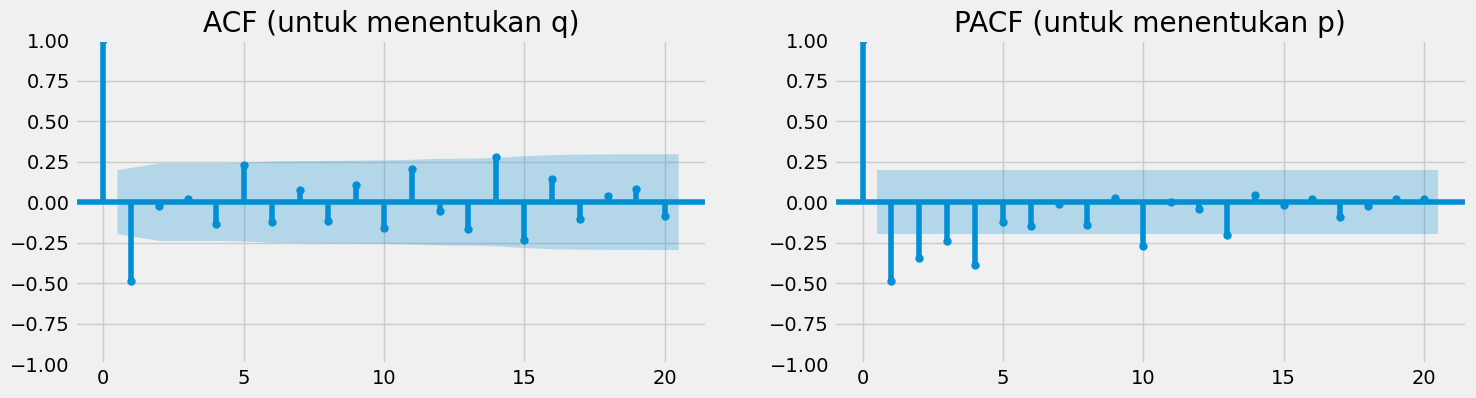

In [89]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df_diff, ax=ax1, title='ACF (untuk menentukan q)')
plot_pacf(df_diff, ax=ax2, title='PACF (untuk menentukan p)')
plt.show()

Langkah 4: Fitting Model ARIMA

In [90]:
# Membagi data train (80) dan test (20)
train = df['Volume'][:80]
test = df['Volume'][80:]

# experiment data test 100


y = 10 + 0.5 * t  + np.random.normal(0,2, 100)
test = pd.DataFrame({'Volume' : y})


# Membangun Model ARIMA(1,1,1)
# Membangun Model ARIMA(p(AutoRegresive),d(Differencing),q(Moving Average))

model =  ARIMA(train, order=(2,1,1))
model_fit = model.fit()
# Menampilkan Ringkasan Model
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 Volume   No. Observations:                   80
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -180.038
Date:                Mon, 25 May 2026   AIC                            368.075
Time:                        22:52:52   BIC                            377.553
Sample:                             0   HQIC                           371.873
                                 - 80                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4869      0.498     -0.978      0.328      -1.462       0.489
ar.L2         -0.2068      0.245     -0.846      0.398      -0.686       0.273
ma.L1         -0.0944      0.515     -0.183      0.8

Langkah 5: Diagnostik Residu

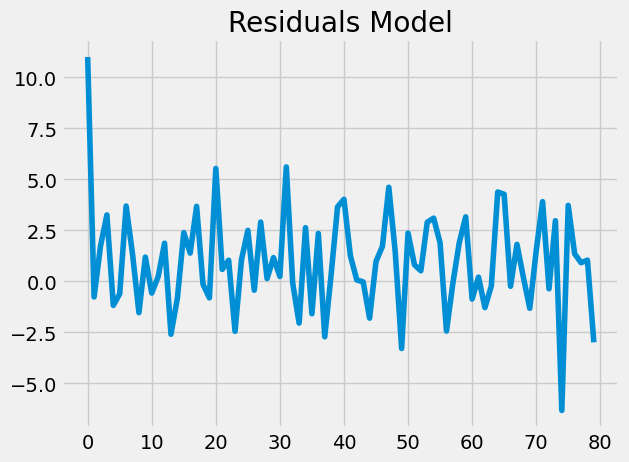

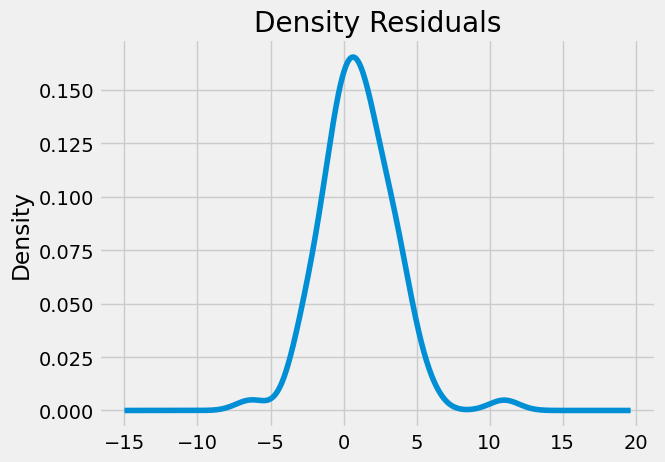

In [91]:
# Plot residu
residuals = model_fit.resid
residuals.plot(title="Residuals Model")
plt.show()
# Plot histogram residu (harus mendekati distribusi normal)
residuals.plot(kind='kde', title='Density Residuals')
plt.show()

Langkah 6: Peramalan (Forecasting)

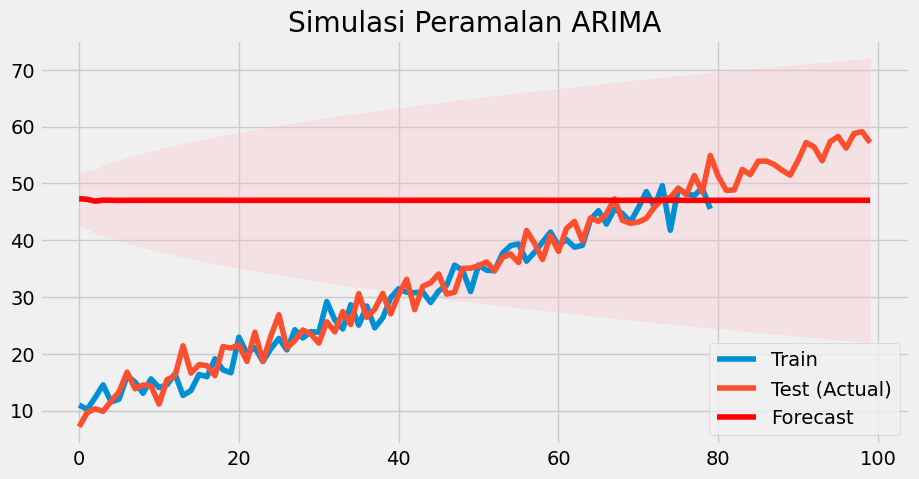

MAPE (Mean Absolute Percentage Error): 79.36%


In [92]:
# Melakukan ramalan untuk 20 langkah ke depan
forecast_obj = model_fit.get_forecast(steps=100)
y_pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()
# Visualisasi Hasil Ramalan
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test (Actual)')
plt.plot(test.index, y_pred, label='Forecast', color='red')
plt.fill_between(test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.legend()
plt.title("Simulasi Peramalan ARIMA")
plt.show()
# Hitung MAPE
mape = mean_absolute_percentage_error(test, y_pred)
print(f"MAPE (Mean Absolute Percentage Error): {mape*100:.2f}%")